## Mounting Gdrive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing Julia

In [2]:
#!curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.7/julia-1.7.2-linux-x86_64.tar.gz" -o julia.tar.gz
!curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.4/julia-1.4.0-linux-x86_64.tar.gz" -o julia.tar.gz
!tar -xzf julia.tar.gz -C /usr --strip-components 1
!rm -rf julia.tar.gz*

### Installing libraries

In [3]:
!julia -e 'using Pkg;ENV["JUPYTER"]="/usr/local/bin/python"; pkg"add IJulia,Distributions,GR,Plots,LaTeXStrings,PyCall,StatsBase,StatsPlots,PyPlot;precompile"'
#!julia -e 'using Pkg;ENV["JUPYTER"]="/usr/local/bin/python"; pkg"add IJulia,Distributions,Plots,PyCall,StatsBase,PyPlot;precompile"'

    Cloning default registries into `~/.julia`
    Cloning registry from "https://github.com/JuliaRegistries/General.git"
      Added registry `General` to `~/.julia/registries/General`
  Resolving package versions...
  Installed LaTeXStrings ───────────────── v1.3.0
  Installed StatsPlots ─────────────────── v0.14.33
  Installed PyCall ─────────────────────── v1.94.1
  Installed IJulia ─────────────────────── v1.23.3
  Installed StatsBase ──────────────────── v0.33.21
  Installed Distributions ──────────────── v0.25.45
  Installed Plots ──────────────────────── v1.6.12
  Installed PyPlot ─────────────────────── v2.11.0
  Installed NetworkOptions ─────────────── v1.2.0
  Installed IteratorInterfaceExtensions ── v1.0.0
  Installed OpenLibm_jll ───────────────── v0.7.1+0
  Installed Tables ─────────────────────── v1.7.0
  Installed NearestNeighbors ───────────── v0.4.11
  Installed NaNMath ────────────────────── v0.3.7
  Installed SpecialFunctions ───────────── v1.8.7
  Installed TableOp

## Installing python dependencies for ploting graphs

In [4]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin
  libgtk2.0-common libgvc6-plugins-gtk libxdot4
0 upgraded, 8 newly installed, 0 to remove and 20 not upgraded.
Need to get 2,120 kB of archives.
After this operation, 7,128 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/main amd64 libgtk2.0-common all 2.24.32-1ubuntu1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu bionic/main amd64 libgtk2.0-0 amd64 2.24.32-1ubuntu1 [1,769 kB]
Get:3 http://archive.ubuntu.com/ubuntu bionic/main

## Installing python requirements to run julia in notebook

In [5]:
!pip install julia 

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 67 kB 3.0 MB/s 


In [6]:
import julia
julia.install()

j = julia.Julia(compiled_modules=False)



In [7]:
%load_ext julia.magic


Initializing Julia interpreter. This may take some time...


In [8]:
from julia import Main as jl  ## not really needed

## Load ABM model

In [9]:
%%julia

rootDir=pwd()*"/drive/MyDrive/"
rootDir=pwd()*"/drive/MyDrive/SYNC_Projects/"

rootDir=rootDir*"pBGT/ms/"

source_path=rootDir*"code/ABM/source/"
workingDir=rootDir*"pBGT/ms/code/Figure_7/"
pathData=rootDir*"data/sim_data/"
pathFigures=rootDir*"figures/"

if ~isdir(pathData)
    mkdir(pathData)
    println("Creating ",pathData)
end
if ~isdir(pathFigures)
    mkdir(pathFigures)
    println("Creating ",pathFigures)
end

#push!(LOAD_PATH,source_path)
source_path

'/content/drive/MyDrive/SYNC_Projects/pBGT/ms/code/ABM/source/'

In [10]:
%%julia

using Distributed
using Distributions,StatsBase,Printf,Random 
import GR
using LaTeXStrings
using StatsPlots
using PyCall
using Serialization
#using PyPlot
using Plots


Plots.scalefontsizes(1.25)
Plots.backend()
ntx = pyimport("networkx")
plt = pyimport("matplotlib.pyplot")

pyplot()


<PyCall.jlwrap Plots.PyPlotBackend()>

In [11]:
!julia -v

julia version 1.4.0


In [12]:
%%julia

include(source_path*"ModelParameters.jl")
include(source_path*"Bacterias.jl")
include(source_path*"CellularFunctions.jl")
include(source_path*"Simulator.jl")
include(source_path*"AnalysisFunctions.jl")
include(source_path*"PlottingFunctions.jl")


### Simulation parameters

In [13]:
%%julia

R0=1.
T=60*8
aA=0.
time_mins=collect(1:T)
starting_variation=true
iniCells=1000

bst=getInitialPopulation(iniCells, mu, 1,starting_variation);
sim_file=pathData*"AntibioticPulse_sim-$(T)min_IniCells-$(iniCells).bacsim"
#sim_filetxt=pathData*"simple_sim-$(T)min.txt"
reDo_sim=false;
@everywhere degAA=1e-10

### Run Simulation 

In [28]:
%%julia

kNoise_dist=Normal(0.,.05)

T=60*8
time_mins=collect(1:T)
aA=pMIC
R0=1.
iniCells=1000
bst=getInitialPopulation(iniCells, mu, 1,starting_variation);
sim_file=pathData*"AntibioticConstantMIC_sim-$(T)min_IniCells-$(iniCells).bacsim"

cv=0.25
p_Ndist=Normal(mu,mu*cv)
antibiotic_action=.9

reDo_sim=true;
reDo_sim=false;
if reDo_sim
    this_bst=Bacteria[]
    this_bst=deepcopy(bst)
    lid=length(bst)

    println("Time\tTotal\tResource         .\tN alive")

    for ti in time_mins
        if ti%30==0
            tparam=0
            for b in this_bst
                b.isDead==false ? tparam+=1 : 0
            end
            println(ti/60,"\t",length(this_bst),"\t",R0,"\t",tparam,"\t",aA)
        end
       R0,aA,lid=simulate(ti, this_bst, R0, aA,antibiotic_action,lid)
    end
    serialize(sim_file, this_bst);
else
    this_bst=deserialize(sim_file);
    print("Loaded saved simulation")
end


In [29]:
%%julia

aA=0.
R0=1.
degAA=1e-20
kNoise_dist=Normal(0.,.01)
pulse_start=3.5
pulse_end=5

iniCells=100
bst=getInitialPopulation(iniCells, mu, 1,starting_variation);
sim_file=pathData*"AntibioticPulse_sim-$(T)min_IniCells-$(iniCells).bacsim"

if reDo_sim
    this_bst=Bacteria[]
    this_bst=deepcopy(bst)
    lid=length(bst)

    println("Time\tTotal\tResource         .\tN alive")

    for ti in time_mins
        
        ti==60*pulse_start ? (aA=pMIC*1.1;println("Introducing antibiotic")) : 0
        ti==60*pulse_end ? (aA=0.;println("Removing antibiotic")) : 0
        
        if ti%30==0
            tparam=0
            batp=0
            tdivs=[]
            for b in this_bst
                b.isDead==false ? tparam+=1 : 0
                b.id==1 ? (batp=b.ATP;tdivs=b.divisions) : 0
            end
            println(ti/60,"\t",length(this_bst),"\t",R0,"\t",tparam,"\t",aA,"\t",batp)#," ",tdivs./60)
            flush(stdout)
        end

        R0,aA,lid=simulate(ti, this_bst, R0, aA,antibiotic_action,lid)

    end
    serialize(sim_file, this_bst);
    #exportCells(this_bst,sim_filetxt);
    
else
    this_bst=deserialize(sim_file);
    #this_bst=importCells(sim_filetxt);
    print("Loaded saved simulation")
end


Loaded saved simulationLoaded saved simulation

In [30]:
%matplotlib inline
%julia pyplot()


<PyCall.jlwrap Plots.PyPlotBackend()>

Got 3 founder survivors
Got 22 founders killed


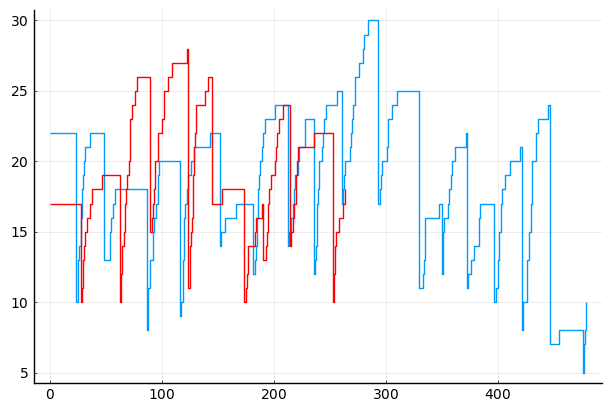

In [31]:
%%julia

survivors=get_Pseries_survivours_indexs(this_bst)
killed=get_Pseries_killed_indexs(this_bst,60*(pulse_start+.5),60*pulse_end)

println("Got $(length(survivors)) founder survivors")
println("Got $(length(killed)) founders killed")

t_surv,p_surv=get_thisBac_Pseries(this_bst,survivors[1])
t_dead,p_dead=get_thisBac_Pseries(this_bst,killed[3])


p=plot(t_surv,p_surv,linetype=:step,legend=false)
plot!(p,t_dead,p_dead,linetype=:step,legend=false,color="red")
#plt.gcf()
display(p)


In [24]:
%%julia

time_Pcounts,time_Pmean=get_FullTimeSeries(time_mins,this_bst)


bin_edges=collect(0:1:30)

time_Pcounts_bins=normalize_FullTimeSeries(time_Pcounts,time_mins,bin_edges)
;

/usr/local/lib/python3.7/dist-packages/julia/magic.py:130: UserWarning: The following kwargs were not used by contour: 'label'
  )(self.shell.user_ns, caller_frame.f_locals)


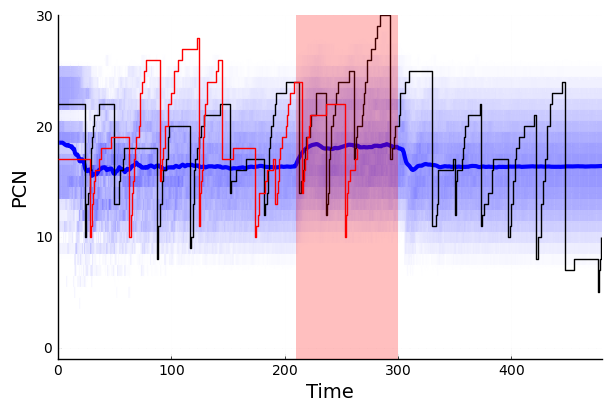

In [25]:
%%julia

colGRAD=cgrad([colorant"white",colorant"blue"])
pdenmax=ceil(maximum(time_Pcounts_bins),digits=1)

p=contour(time_mins,bin_edges,time_Pcounts_bins,colorbar=false,fill=true,lw=0, color=colGRAD,alpha=.75,xlabel="Time", ylabel="PCN",clim=(.01,pdenmax))
p=heatmap!(p,time_mins,bin_edges,time_Pcounts_bins,colorbar=false, color=colGRAD,alpha=.75,xlabel="Time", ylabel="PCN")
plot!(p,time_Pmean,color="blue",lw=3,legend=false)
plot!(p,t_surv,p_surv,linetype=:step,legend=false,color="black")
plot!(p,t_dead,p_dead,linetype=:step,legend=false,color="red")
vspan!([pulse_start,pulse_end].*60,color="red",alpha=.25)
plot!(p,xlim=(0,time_mins[end]),ylim=(-1,bin_edges[end] ))
#plot!(p,fill = 0, fillalpha = 0.5,fillcolor = :red)
display(p)


## The real show

In [27]:
%%julia


T=60*8
aA=0.
time_mins=collect(1:T)
starting_variation=true
iniCells=1000
aA=0.
R0=1.

degAA=1e-20
kNoise_dist=Normal(0.,.05)
pulse_start=3.5
pulse_end=5

iniCells=1000
bst=getInitialPopulation(iniCells, mu, 1,starting_variation);
sim_file2=pathData*"AntibioticPulse_sim-$(T)min_IniCells-$(iniCells)2.bacsim"

reDo_sim=true
reDo_sim=false
if reDo_sim
    #this_bst2=Bacteria[]
    this_bst2=deepcopy(bst)
    lid=length(bst)

    println("Time\tTotal\tResource         .\tN alive")

    for ti in time_mins
        
        ti==60*pulse_start ? (aA=pMIC*1;println("Introducing antibiotic")) : 0
        ti==60*pulse_end ? (aA=0.;println("Removing antibiotic")) : 0
        
        if ti%30==0
            tparam=0
            batp=0
            tdivs=[]
            for b in this_bst2
                b.isDead==false ? tparam+=1 : 0
                b.id==1 ? (batp=b.ATP;tdivs=b.divisions) : 0
            end
            println(ti/60,"\t",length(this_bst2),"\t",R0,"\t",tparam,"\t",aA,"\t",batp)#," ",tdivs./60)
            flush(stdout)
        end

        R0,aA,lid=simulate_nodaughters(ti, this_bst2, R0, aA,antibiotic_action,lid)

    end
    serialize(sim_file2, this_bst2);
    #exportCells(this_bst,sim_filetxt);
    
else
    this_bst2=deserialize(sim_file2);
    #this_bst=importCells(sim_filetxt);
    print("Loaded saved simulation")
end

survivors2=get_Pseries_survivours_indexs(this_bst2)
killed2=get_Pseries_killed_indexs(this_bst2,60*(pulse_start+.5),60*pulse_end)

println("Got $(length(survivors2)) founder survivors")
println("Got $(length(killed2)) founders killed")


Loaded saved simulationGot 44 founder survivors
Got 268 founders killed



Saving figure /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/Fig-7D.pdf ..

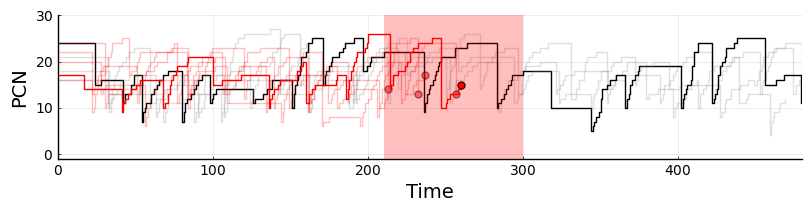

In [26]:
%%julia

pp=plot(size=(800,200))
for (i,is) in enumerate(survivors2[1:4])
    i==3 ? (talpha=1;tcolor="black") : (talpha=.25;tcolor="gray")
    t_surv2,p_surv2=get_thisBac_Pseries(this_bst2,is)
    plot!(pp,t_surv2,p_surv2,linetype=:step,legend=false,color=tcolor,alpha=talpha)    
end


cc=0
killed3=deepcopy(killed2)
shuffle!(killed3)
for (i,this_killed) in enumerate(killed3)
    
    i==5 ? continue : 0
    t_dead2,p_dead2=get_thisBac_Pseries(this_bst2,this_killed)
    p_dead2[end]<mu ?  (global cc+=1) : continue
    
    plot!(pp,t_dead2,p_dead2,linetype=:step,legend=false,color="red",alpha=.25)
    scatter!(pp,[t_dead2[end]],[p_dead2[end]],color="red",m=5,alpha=.5)
    
    cc >=4 ? break : 0
end

t_dead2,p_dead2=get_thisBac_Pseries(this_bst2,killed2[5])
plot!(pp,t_dead2,p_dead2,linetype=:step,legend=false,color="red")
scatter!(pp,[t_dead2[end]],[p_dead2[end]],color="red",m=5)

vspan!(pp,[pulse_start,pulse_end].*60,color="red",alpha=.25)
plot!(pp,xlim=(0,time_mins[end]),ylim=(-1,bin_edges[end]),xlabel="Time",ylabel="PCN")
#pp=plt.gcf()

figname=pathFigures*"Fig-7D.pdf"
println("Saving figure $figname ..")
savefig(pp,figname)
display(pp)